# Risk Metrics Analysis

**Key question:** Does the asymmetric exit logic (market orders for exits) reduce drawdown duration?

Covers: drawdown periods, vol targeting adherence, exit speed, exposure constraints.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

DATA_DIR     = './output'
TARGET_VOL   = 0.10
MAX_GROSS    = 1.50
MAX_NET      = 0.50
print('Config OK')

Config OK


In [2]:
snap = pd.read_csv(f'{DATA_DIR}/daily_snapshots.csv', parse_dates=['date'], index_col='date').sort_index()
oe   = pd.read_csv(f'{DATA_DIR}/order_events.csv',   parse_dates=['date'])
print(f'Snapshots: {len(snap)} | Order events: {len(oe)}')
snap.head(3)

Snapshots: 523 | Order events: 3631


,nav,cash,gross_exposure,net_exposure,long_exposure,short_exposure,daily_pnl,cumulative_pnl,daily_slippage,num_positions,estimated_vol
date,,,,,,,,,,,
2020-01-01,100000.00,100000.00,0.0000,0.0000,0.0000,0.0000,0.00,0.00,0.0,0,NaN
2020-01-02,99907.29,102749.09,0.0511,-0.0284,0.0113,0.0398,-92.71,-92.71,0.0,17,NaN
2020-01-03,99892.23,98632.21,0.1035,0.0126,0.0581,0.0455,-15.07,-107.77,0.0,24,NaN


In [3]:
# Drawdown analysis
ret      = snap['nav'].pct_change().dropna()
cum      = (1 + ret).cumprod()
roll_max = cum.cummax()
dd       = (cum - roll_max) / roll_max

# Identify distinct drawdown periods
in_dd = dd < -0.001
dd_periods = []
start = None
for date, val in in_dd.items():
    if val and start is None:
        start = date
    elif not val and start is not None:
        dd_periods.append({
            'start': start, 'end': date,
            'duration_days': (date - start).days,
            'max_dd_pct': dd[start:date].min() * 100
        })
        start = None

dd_df = pd.DataFrame(dd_periods).sort_values('max_dd_pct')
print(f'Drawdown periods   : {len(dd_df)}')
print(f'Max drawdown       : {dd.min()*100:.2f}%')
print(f'Avg DD duration    : {dd_df["duration_days"].mean():.1f} days')
print(f'Longest DD         : {dd_df["duration_days"].max()} days')
dd_df.head(10)

Drawdown periods   : 4
Max drawdown       : -6.16%
Avg DD duration    : 58.0 days
Longest DD         : 226 days


,start,end,duration_days,max_dd_pct
0,2020-01-06,2020-08-19,226,-2.185016
3,2020-09-21,2020-09-23,2,-0.126422
2,2020-09-14,2020-09-15,1,-0.124288
1,2020-09-04,2020-09-07,3,-0.106868


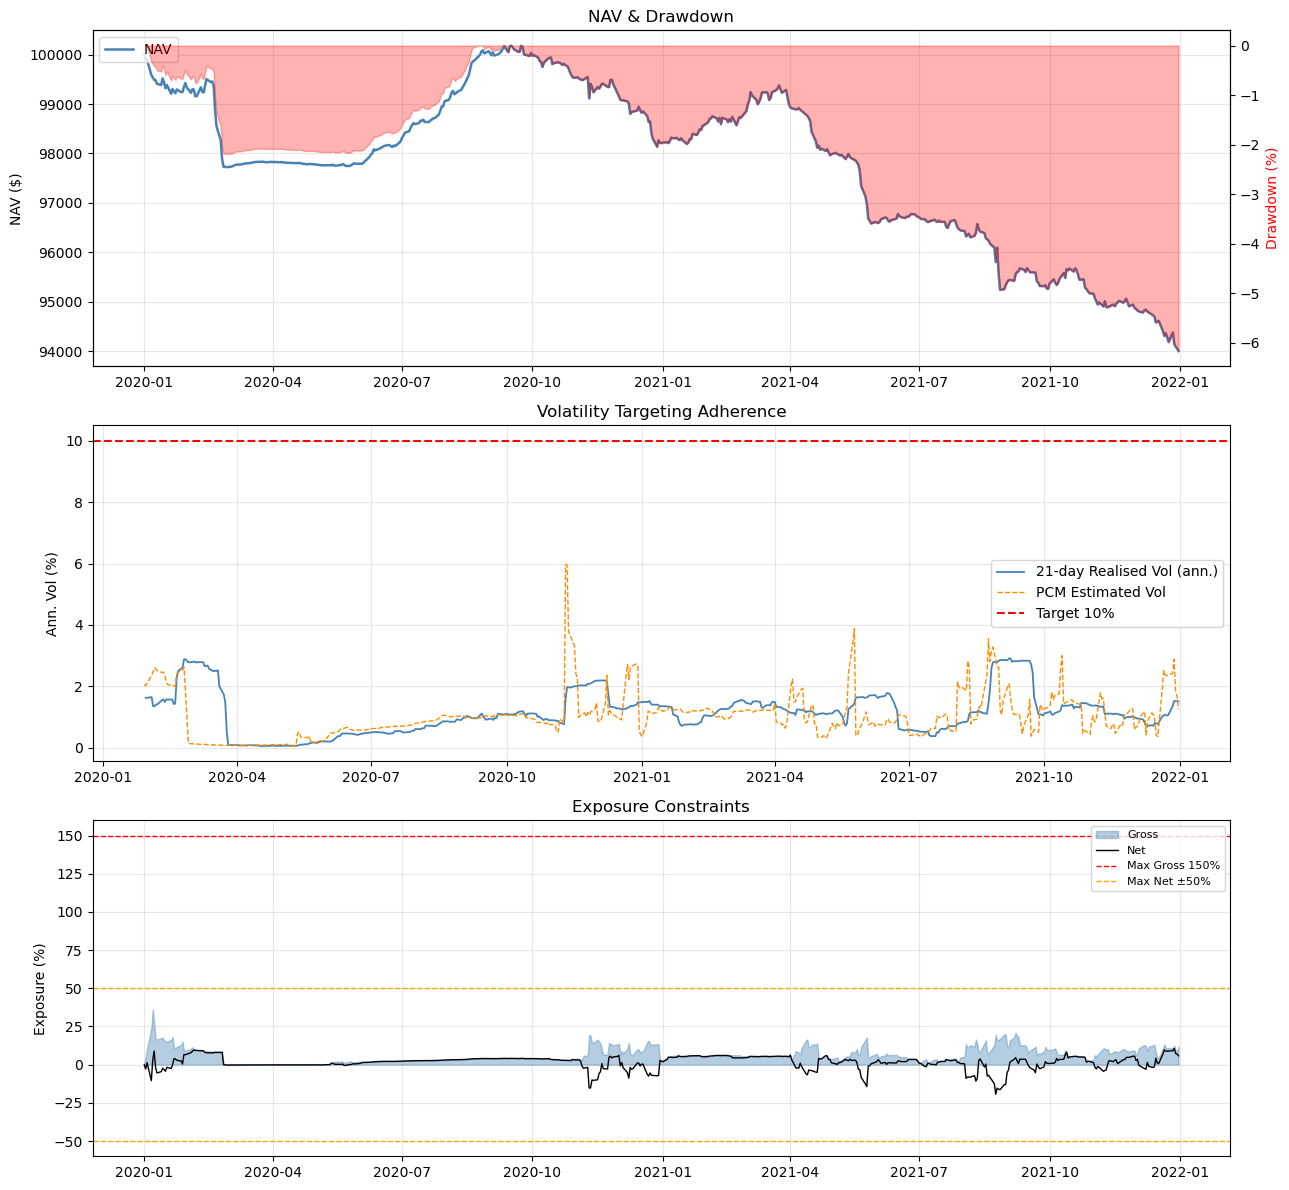

In [4]:
roll_vol = ret.rolling(21).std() * np.sqrt(252)
est_vol  = snap['estimated_vol'].replace('', np.nan).astype(float) if 'estimated_vol' in snap.columns else None

fig, axes = plt.subplots(3, 1, figsize=(13, 12))

# NAV + drawdown
ax = axes[0]
ax2 = ax.twinx()
ax.plot(snap['nav'], color='steelblue', lw=1.8, label='NAV')
ax2.fill_between(dd.index, dd.values*100, 0, alpha=0.3, color='red', label='Drawdown')
ax.set_title('NAV & Drawdown', fontsize=12); ax.set_ylabel('NAV ($)')
ax2.set_ylabel('Drawdown (%)', color='red')
ax.legend(loc='upper left'); ax.grid(alpha=0.3)

# Vol targeting
ax = axes[1]
ax.plot(roll_vol.index, roll_vol*100, color='steelblue', lw=1.3, label='21-day Realised Vol (ann.)')
if est_vol is not None:
    ax.plot(est_vol.dropna().index, est_vol.dropna()*100, color='darkorange',
            lw=1, ls='--', label='PCM Estimated Vol')
ax.axhline(TARGET_VOL*100, color='red', lw=1.5, ls='--', label=f'Target {TARGET_VOL*100:.0f}%')
ax.set_title('Volatility Targeting Adherence', fontsize=12)
ax.set_ylabel('Ann. Vol (%)'); ax.legend(); ax.grid(alpha=0.3)

# Exposure
ax = axes[2]
ax.fill_between(snap.index, snap['gross_exposure']*100, alpha=0.4, color='steelblue', label='Gross')
ax.plot(snap.index, snap['net_exposure']*100, color='black', lw=1, label='Net')
ax.axhline(MAX_GROSS*100, color='red',    lw=1, ls='--', label=f'Max Gross {MAX_GROSS*100:.0f}%')
ax.axhline(MAX_NET*100,   color='orange', lw=1, ls='--', label=f'Max Net ±{MAX_NET*100:.0f}%')
ax.axhline(-MAX_NET*100,  color='orange', lw=1, ls='--')
ax.set_title('Exposure Constraints', fontsize=12)
ax.set_ylabel('Exposure (%)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/risk_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

Time-to-fill (days):
  Exits  (market): mean=nan  median=nan
  Entries (limit): mean=2.07  median=1.0


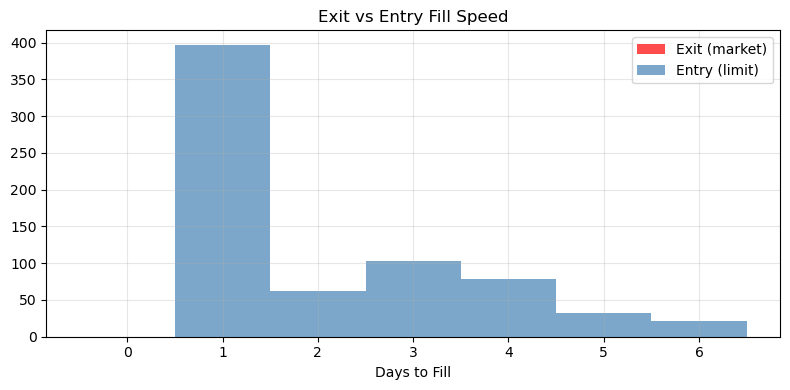

In [5]:
# Exit speed: market orders (exits) vs limit orders (entries)
if 'tag' in oe.columns and 'status' in oe.columns:
    filled = oe[oe['status']=='Filled'].copy()
    filled['is_exit'] = filled['tag'].str.contains('exit', case=False, na=False)

    # Submit-to-fill delay
    submit = oe[oe['status']=='Submitted'].groupby('order_id')['date'].min()
    fill   = filled.groupby('order_id')['date'].max()
    ttf    = (fill - submit).dt.days.clip(lower=0).rename('ttf')
    filled = filled.join(ttf, on='order_id')

    exit_ttf  = filled[filled['is_exit']]['ttf'].dropna()
    entry_ttf = filled[~filled['is_exit']]['ttf'].dropna()

    print('Time-to-fill (days):')
    print(f'  Exits  (market): mean={exit_ttf.mean():.2f}  median={exit_ttf.median()}')
    print(f'  Entries (limit): mean={entry_ttf.mean():.2f}  median={entry_ttf.median()}')

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(exit_ttf,  bins=range(0,8), alpha=0.7, label='Exit (market)', color='red',       align='left')
    ax.hist(entry_ttf, bins=range(0,8), alpha=0.7, label='Entry (limit)', color='steelblue', align='left')
    ax.set_xlabel('Days to Fill'); ax.set_title('Exit vs Entry Fill Speed', fontsize=12)
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

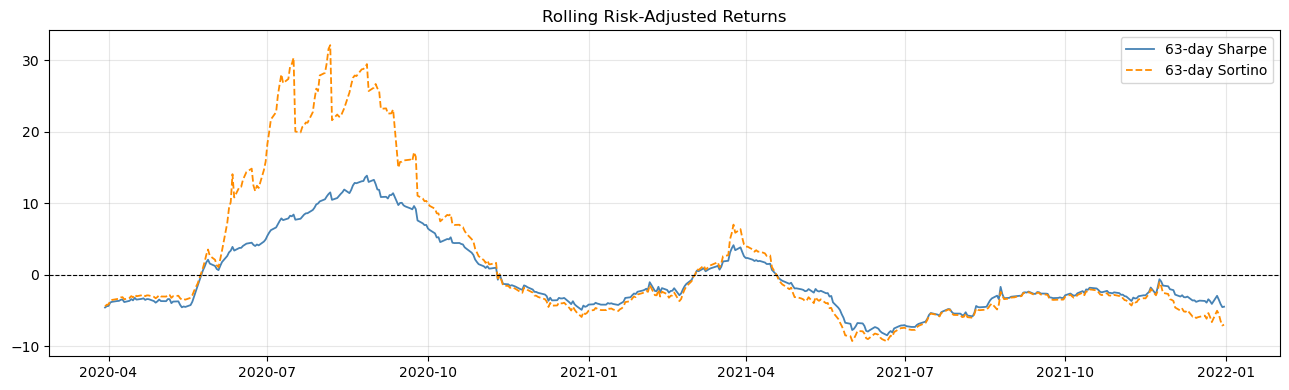

In [6]:
# Rolling Sharpe & Sortino
window = 63
roll_sharpe  = ret.rolling(window).apply(
    lambda x: x.mean()/x.std()*np.sqrt(252) if x.std()>0 else np.nan, raw=True)
roll_sortino = ret.rolling(window).apply(
    lambda x: x.mean()/x[x<0].std()*np.sqrt(252) if x[x<0].std()>0 else np.nan, raw=True)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(roll_sharpe,  label=f'{window}-day Sharpe',  color='steelblue', lw=1.3)
ax.plot(roll_sortino, label=f'{window}-day Sortino', color='darkorange', lw=1.3, ls='--')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title('Rolling Risk-Adjusted Returns', fontsize=12)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [7]:
print('=== Constraint Violations ===')
print(f'Gross > {MAX_GROSS*100:.0f}%  : {(snap["gross_exposure"] > MAX_GROSS).sum()} days')
print(f'|Net| > {MAX_NET*100:.0f}%   : {(snap["net_exposure"].abs() > MAX_NET).sum()} days')
print(f'Vol   > {TARGET_VOL*150:.0f}% (1.5x target): {(roll_vol > TARGET_VOL*1.5).sum()} days')

=== Constraint Violations ===
Gross > 150%  : 0 days
|Net| > 50%   : 0 days
Vol   > 15% (1.5x target): 0 days
